#  Experiment 3: Baseline - Separable vs Entangled on Simple Data

## Phase 1 Exploration: Does Entanglement Help for Simple Music?

**Research Question:** For simple musical data (Mario - pitch only), does entanglement provide an advantage? Or can a separable circuit learn equally well?

**Experimental Design:**
- Dataset: Super Mario Bros (pitch only, 4 qubits)
- Model A: Separable QCBM (topology='none')
- Model B: Entangled QCBM (topology='full')
- Loss: MMD with RBF kernel
- Optimizer: Powell
- Iterations: 200

---

In [12]:
# Setup and imports
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
from time import time

from src.models.qcbm import QCBM, create_separable_qcbm, create_entangled_qcbm
from src.data.datasets import get_mario_dataset
from src.training.trainer import Trainer, train_qcbm
from src.training.loss_functions import fidelity
from src.utils.visualization import (
    set_style, plot_distribution, plot_distributions_comparison,
    plot_loss_curve, plot_multiple_loss_curves
)
from src.utils.metrics import compute_all_metrics
from src.utils.figure_saver import save_figure
from config import MIDI_DIR, FIGURES_DIR, RANDOM_SEED

set_style()
np.random.seed(RANDOM_SEED)
print(" Setup complete!")

 Setup complete!


## 1. Load Target Distribution

 Dataset: Simple_4q
   States: 16
   Entropy: 3.51 bits
   Sparsity: 0.0%
 Figure saved: /home/jacopo/Documenti/Trento/QuantumML/MusicProject/notebooks/../results/figures/exp03_mario_target_distribution.png
 Figure saved: /home/jacopo/Documenti/Trento/QuantumML/MusicProject/notebooks/../results/figures/exp03_mario_target_distribution.png


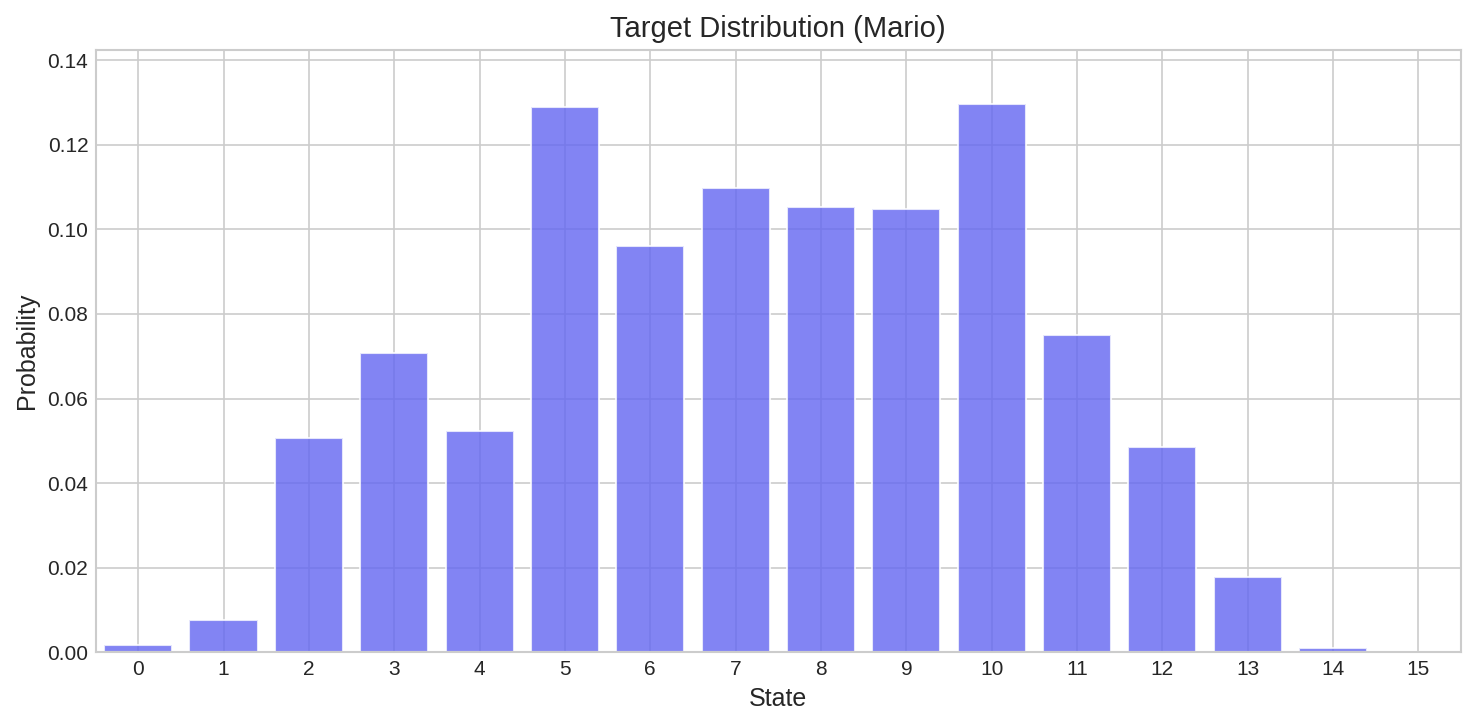

In [13]:
# Load the Mario dataset
dataset = get_mario_dataset(n_qubits=4, midi_path=str(MIDI_DIR / 'mario.mid'))
target = dataset.distribution

print(f" Dataset: {dataset.name}")
print(f"   States: {dataset.n_states}")
print(f"   Entropy: {dataset.entropy:.2f} bits")
print(f"   Sparsity: {100 * dataset.sparsity:.1f}%")

# Visualize target
fig, ax = plt.subplots(figsize=(10, 5))
plot_distribution(target, title='Target Distribution (Mario)', ax=ax)
plt.tight_layout()
save_figure(fig, 'mario_target_distribution', experiment='exp03')
plt.show()

## 2. Create Models

In [14]:
# Configuration
N_QUBITS = 4
N_LAYERS = 3
N_ITERATIONS = 200

# Create both models
separable_qcbm = create_separable_qcbm(n_qubits=N_QUBITS, n_layers=N_LAYERS)
entangled_qcbm = create_entangled_qcbm(n_qubits=N_QUBITS, n_layers=N_LAYERS)

print(" Model Configurations:")
print("=" * 50)
print(f"\n SEPARABLE (Classical Baseline):")
print(f"   {separable_qcbm}")
print(f"   Parameters: {separable_qcbm.n_params}")

print(f"\n ENTANGLED (Quantum):")
print(f"   {entangled_qcbm}")
print(f"   Parameters: {entangled_qcbm.n_params}")

 Model Configurations:

 SEPARABLE (Classical Baseline):
   QCBM(n_qubits=4, n_layers=3, topology='none')
   Parameters: 24

 ENTANGLED (Quantum):
   QCBM(n_qubits=4, n_layers=3, topology='full')
   Parameters: 24


## 3. Train Separable Model

In [15]:
print(" Training SEPARABLE QCBM...")
print("=" * 50)

separable_result = train_qcbm(
    qcbm=separable_qcbm,
    target_distribution=target,
    n_iterations=N_ITERATIONS,
    loss_function='mmd',
    optimizer='Powell',
    verbose=True,
    seed=RANDOM_SEED
)

print("\n" + separable_result.summary())

 Training SEPARABLE QCBM...


Training QCBM: 892it [00:03, 223.74it/s, loss=0.0745, fidelity=0.6329]                         
Training QCBM: 892it [00:03, 223.74it/s, loss=0.0745, fidelity=0.6329]



Training Summary:
  Optimizer: Powell
  Loss Function: mmd
  Iterations: 892
  Final Loss: 0.074540
  Best Loss: 0.074540
  Final Fidelity: 0.6329
  Total Time: 3.97s
  Time/Step: 0.0035s
  Converged: True


## 4. Train Entangled Model

In [16]:
print(" Training ENTANGLED QCBM...")
print("=" * 50)

entangled_result = train_qcbm(
    qcbm=entangled_qcbm,
    target_distribution=target,
    n_iterations=N_ITERATIONS,
    loss_function='mmd',
    optimizer='Powell',
    verbose=True,
    seed=RANDOM_SEED
)

print("\n" + entangled_result.summary())

 Training ENTANGLED QCBM...


Training QCBM: 2000it [00:13, 148.40it/s, loss=0.0000, fidelity=0.8256]                        


Training Summary:
  Optimizer: Powell
  Loss Function: mmd
  Iterations: 2000
  Final Loss: 0.000047
  Best Loss: 0.000047
  Final Fidelity: 0.8256
  Total Time: 13.48s
  Time/Step: 0.0059s
  Converged: False


## 5. Compare Training Curves

 Figure saved: /home/jacopo/Documenti/Trento/QuantumML/MusicProject/notebooks/../results/figures/exp03_training_curves.png


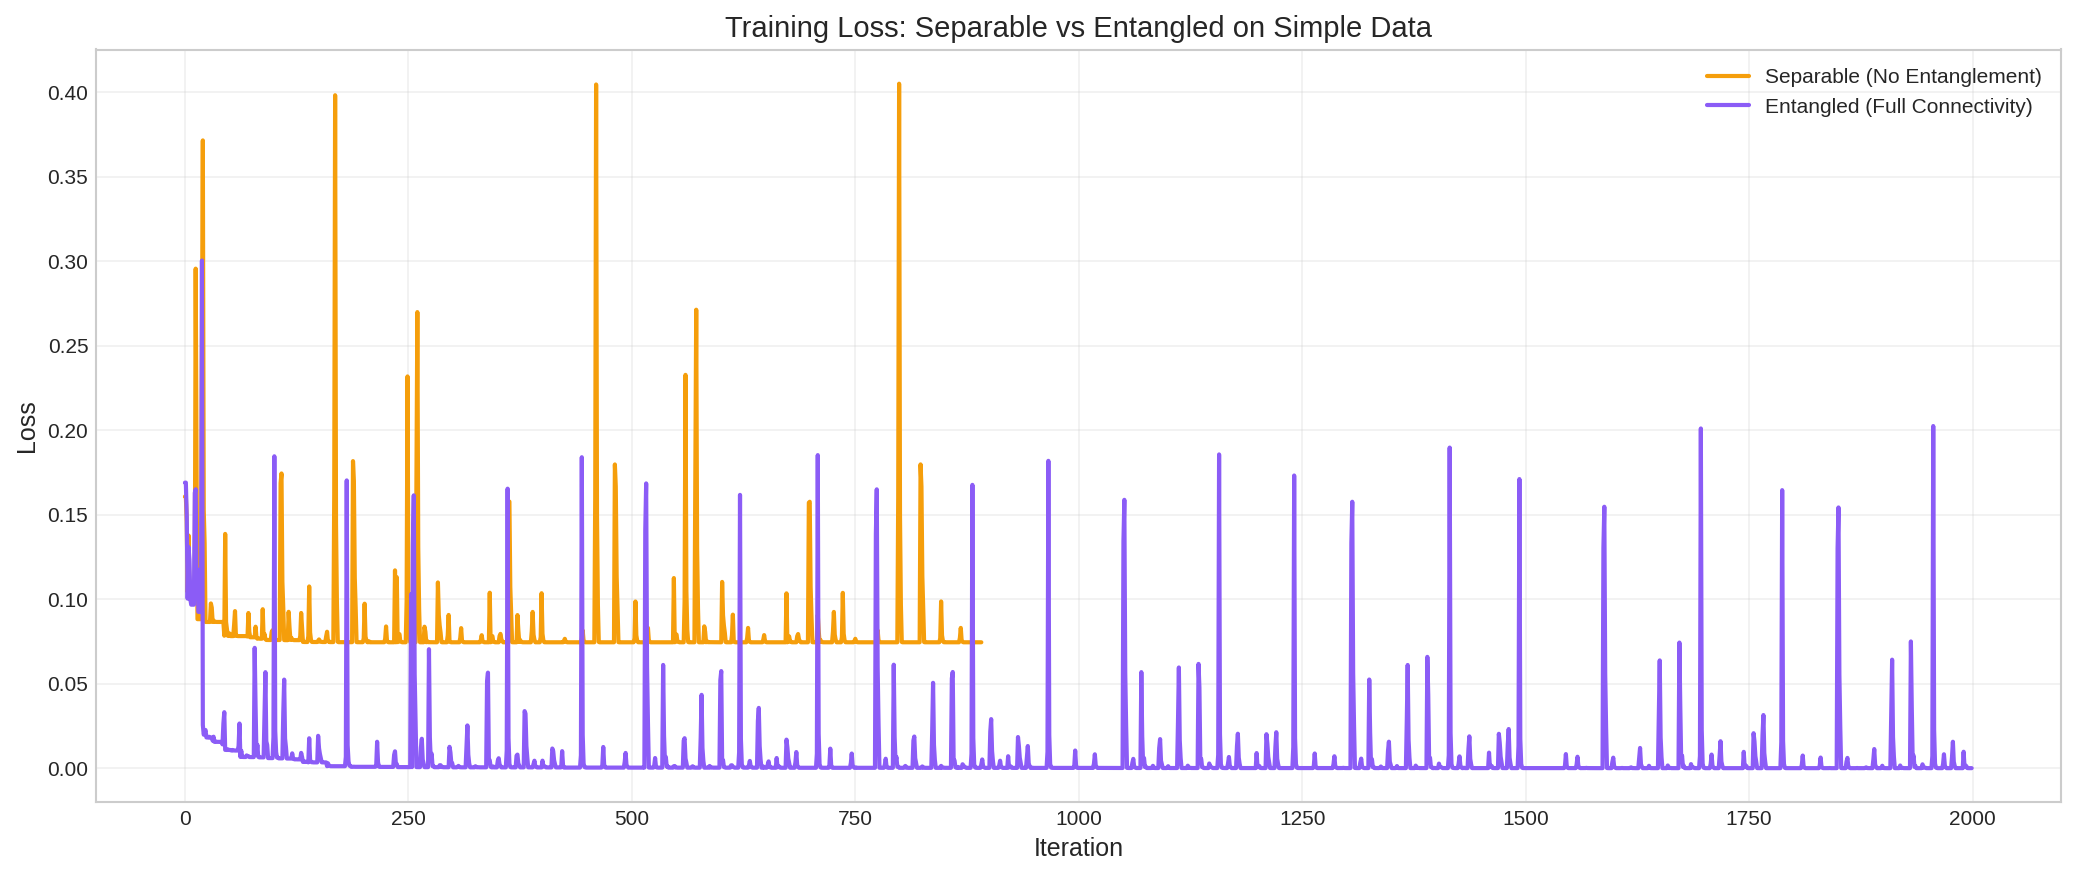

 Figure saved: /home/jacopo/Documenti/Trento/QuantumML/MusicProject/notebooks/../results/figures/exp03_fidelity_curves.png


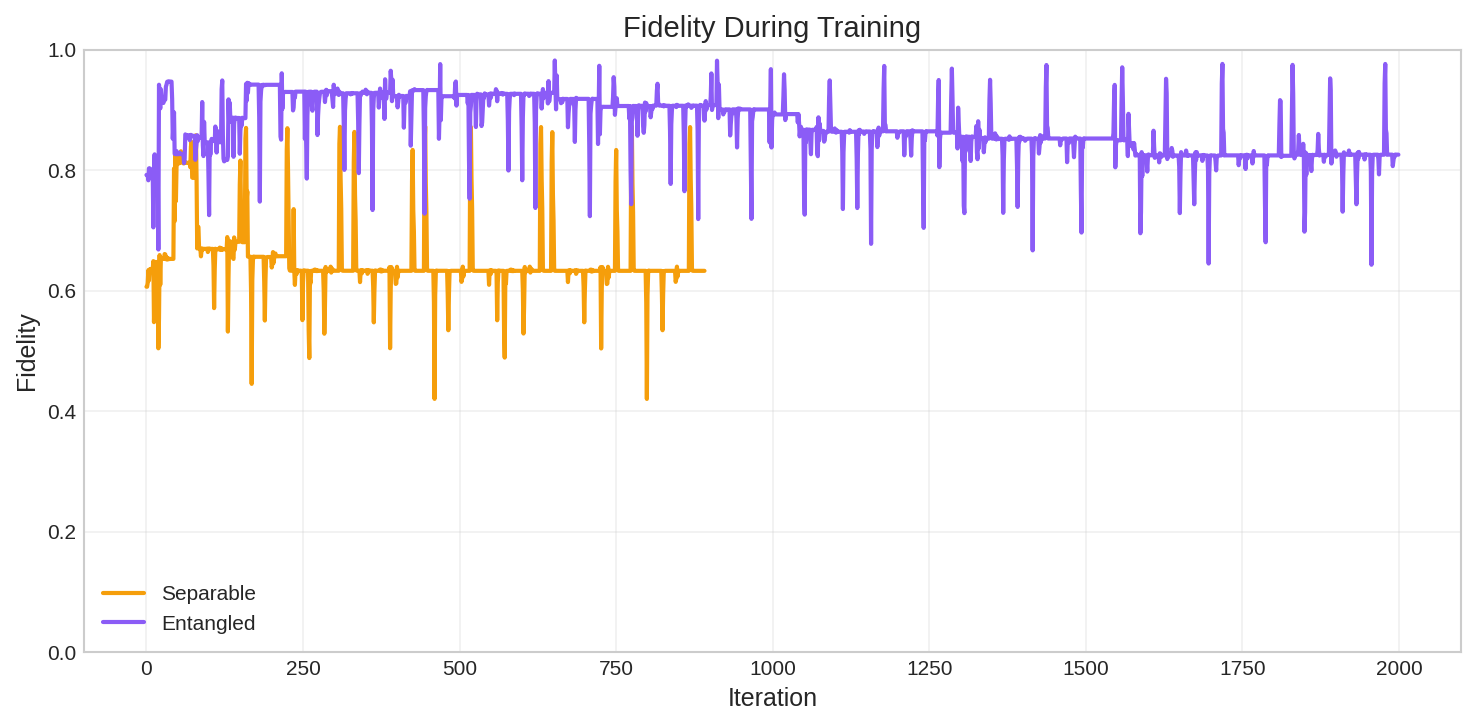

In [17]:
# Plot training curves
fig = plot_multiple_loss_curves(
    {
        'Separable (No Entanglement)': separable_result.loss_history,
        'Entangled (Full Connectivity)': entangled_result.loss_history
    },
    title='Training Loss: Separable vs Entangled on Simple Data',
    colors={
        'Separable (No Entanglement)': '#F59E0B',
        'Entangled (Full Connectivity)': '#8B5CF6'
    }
)
save_figure(fig, 'training_curves', experiment='exp03')
plt.show()

# Plot fidelity curves
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(separable_result.fidelity_history, label='Separable', color='#F59E0B', linewidth=2)
ax.plot(entangled_result.fidelity_history, label='Entangled', color='#8B5CF6', linewidth=2)
ax.set_xlabel('Iteration')
ax.set_ylabel('Fidelity')
ax.set_title('Fidelity During Training')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1)
plt.tight_layout()
save_figure(fig, 'fidelity_curves', experiment='exp03')
plt.show()

## 6. Compare Final Distributions

 Figure saved: /home/jacopo/Documenti/Trento/QuantumML/MusicProject/notebooks/../results/figures/exp03_distribution_comparison.png


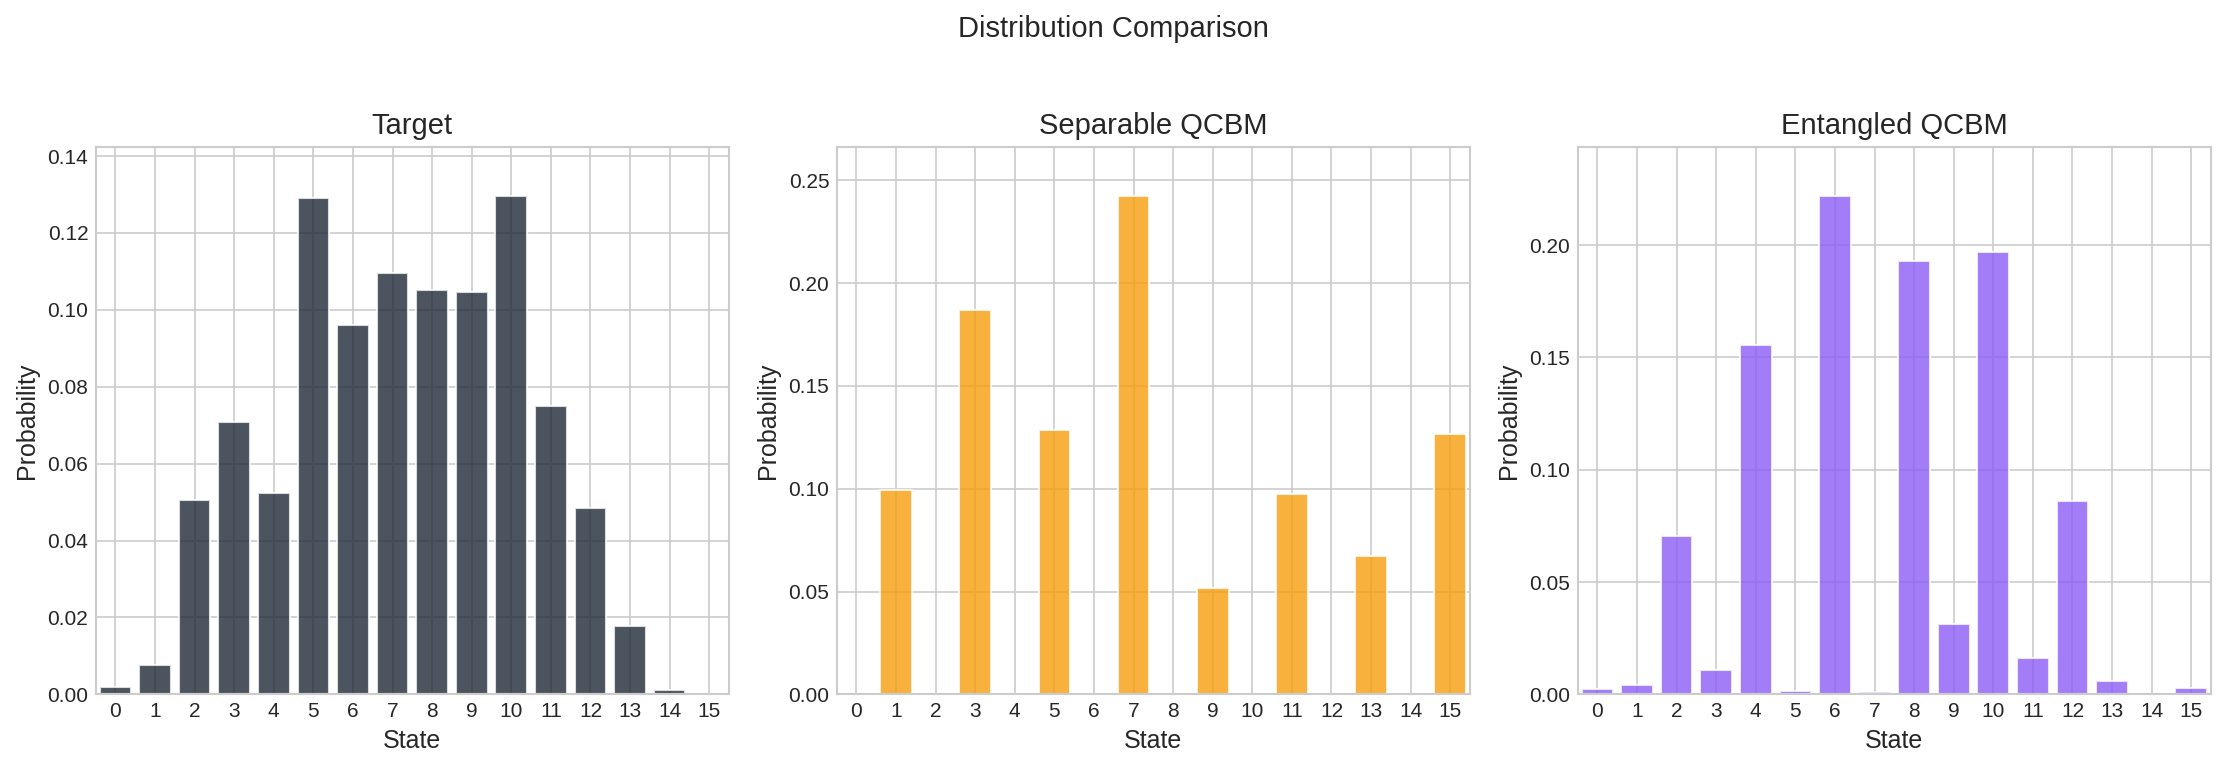

In [18]:
# Get final distributions
separable_final = separable_qcbm.get_probabilities(separable_result.final_params)
entangled_final = entangled_qcbm.get_probabilities(entangled_result.final_params)

# Plot comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

plot_distribution(target, title='Target', ax=axes[0], color='#1F2937')
plot_distribution(separable_final, title='Separable QCBM', ax=axes[1], color='#F59E0B')
plot_distribution(entangled_final, title='Entangled QCBM', ax=axes[2], color='#8B5CF6')

plt.suptitle('Distribution Comparison', fontsize=14, y=1.02)
plt.tight_layout()
save_figure(fig, 'distribution_comparison', experiment='exp03')
plt.show()

## 7. Quantitative Comparison

In [19]:
# Compute all metrics
separable_metrics = compute_all_metrics(separable_final, target)
entangled_metrics = compute_all_metrics(entangled_final, target)

print(" FINAL METRICS COMPARISON")
print("=" * 60)
print(f"\n{'Metric':<25} {'Separable':<15} {'Entangled':<15} {'Winner':<10}")
print("-" * 65)

metrics_names = ['MMD', 'KL Divergence', 'Total Variation', 'Hellinger Distance', 'Fidelity']
sep_dict = separable_metrics.to_dict()
ent_dict = entangled_metrics.to_dict()

for metric in metrics_names:
    sep_val = sep_dict[metric]
    ent_val = ent_dict[metric]
    
    # For fidelity, higher is better; for others, lower is better
    if metric == 'Fidelity':
        winner = ' Sep' if sep_val > ent_val else ' Ent'
    else:
        winner = ' Sep' if sep_val < ent_val else ' Ent'
    
    print(f"{metric:<25} {sep_val:<15.6f} {ent_val:<15.6f} {winner}")

# Training efficiency
print(f"\n{'Training Time (s)':<25} {separable_result.total_time:<15.2f} {entangled_result.total_time:<15.2f}")
print(f"{'Avg Time/Step (s)':<25} {np.mean(separable_result.time_per_step):<15.4f} {np.mean(entangled_result.time_per_step):<15.4f}")

 FINAL METRICS COMPARISON

Metric                    Separable       Entangled       Winner    
-----------------------------------------------------------------
MMD                       0.074540        0.000047         Ent
KL Divergence             1.533509        0.532260         Ent
Total Variation           0.538435        0.444547         Ent
Hellinger Distance        0.605913        0.417638         Ent
Fidelity                  0.632869        0.825578         Ent

Training Time (s)         3.97            13.48          
Avg Time/Step (s)         0.0035          0.0059         


## 8. Statistical Analysis

In [20]:
# Run multiple trials for statistical significance
N_TRIALS = 5

print(f" Running {N_TRIALS} trials for statistical analysis...")
print("=" * 50)

separable_losses = []
entangled_losses = []
separable_times = []
entangled_times = []

for trial in range(N_TRIALS):
    print(f"\nTrial {trial + 1}/{N_TRIALS}...")
    
    # Train separable
    sep_model = create_separable_qcbm(n_qubits=N_QUBITS, n_layers=N_LAYERS)
    sep_result = train_qcbm(
        sep_model, target, n_iterations=100, 
        verbose=False, seed=RANDOM_SEED + trial
    )
    separable_losses.append(sep_result.final_loss)
    separable_times.append(sep_result.total_time)
    
    # Train entangled
    ent_model = create_entangled_qcbm(n_qubits=N_QUBITS, n_layers=N_LAYERS)
    ent_result = train_qcbm(
        ent_model, target, n_iterations=100,
        verbose=False, seed=RANDOM_SEED + trial
    )
    entangled_losses.append(ent_result.final_loss)
    entangled_times.append(ent_result.total_time)

print("\n STATISTICAL RESULTS")
print("=" * 50)
print(f"\n{'Metric':<20} {'Separable':<25} {'Entangled':<25}")
print("-" * 70)
print(f"{'Final Loss':<20} {np.mean(separable_losses):.4f} ± {np.std(separable_losses):.4f}    {np.mean(entangled_losses):.4f} ± {np.std(entangled_losses):.4f}")
print(f"{'Training Time (s)':<20} {np.mean(separable_times):.2f} ± {np.std(separable_times):.2f}      {np.mean(entangled_times):.2f} ± {np.std(entangled_times):.2f}")

 Running 5 trials for statistical analysis...

Trial 1/5...

Trial 2/5...

Trial 2/5...

Trial 3/5...

Trial 3/5...

Trial 4/5...

Trial 4/5...

Trial 5/5...

Trial 5/5...

 STATISTICAL RESULTS

Metric               Separable                 Entangled                
----------------------------------------------------------------------
Final Loss           0.0745 ± 0.0000    0.0010 ± 0.0016
Training Time (s)    2.25 ± 0.38      4.85 ± 0.05

 STATISTICAL RESULTS

Metric               Separable                 Entangled                
----------------------------------------------------------------------
Final Loss           0.0745 ± 0.0000    0.0010 ± 0.0016
Training Time (s)    2.25 ± 0.38      4.85 ± 0.05


##  Conclusions

### Key Findings:

Based on the experimental results above, compare the fidelity values to determine which model performs better.

**Analysis Notes:**
- If entangled fidelity is significantly higher → Entanglement helps even on "simple" data
- If fidelities are similar → Entanglement may not be necessary for this distribution
- Training time differences show computational cost of entangling gates

### Scientific Insight:

> When the target distribution can be factorized as a product of marginals:
> $$P(x_1, x_2, ..., x_n) = P(x_1) \cdot P(x_2) \cdot ... \cdot P(x_n)$$
> 
> A separable quantum state may suffice. However, even "simple" music like Mario may have subtle correlations that benefit from entanglement.

### Next Experiment:
→ **Notebook 04:** Test scalability with different numbers of qubits and layers

In [21]:
# Save results
import json

results = {
    'experiment': 'baseline_simple',
    'dataset': 'mario',
    'separable': {
        'final_loss': float(separable_result.final_loss),
        'final_fidelity': float(separable_result.final_fidelity),
        'total_time': float(separable_result.total_time),
        'n_iterations': separable_result.n_iterations
    },
    'entangled': {
        'final_loss': float(entangled_result.final_loss),
        'final_fidelity': float(entangled_result.final_fidelity),
        'total_time': float(entangled_result.total_time),
        'n_iterations': entangled_result.n_iterations
    }
}

with open(FIGURES_DIR / 'exp03_baseline_results.json', 'w') as f:
    json.dump(results, f, indent=2)

print(f" Results saved to {FIGURES_DIR / 'exp03_baseline_results.json'}")

 Results saved to /home/jacopo/Documenti/Trento/QuantumML/MusicProject/notebooks/../results/figures/exp03_baseline_results.json


In [22]:
from src.utils.figure_saver import save_current_figure